In [3]:
# ! pip install glasbey

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import glasbey

In [5]:
filename = r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\combined_matrix_2lc.csv'
data = pd.read_csv( filename , index_col=0)

In [6]:
grouped_filename = r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\cluster_groups_matlab.csv'
groups = pd.read_csv( grouped_filename )

In [7]:
def map_grouped_clusters(df):
    return df.merge(groups[['Cluster', 'Group']], left_on='Cluster', right_on='Cluster', how='left')


new_data = map_grouped_clusters( data )

In [8]:
data = new_data

In [9]:
# Automatically find the number of stages
weeks = data['Week_Number'].unique()
stage_names = [f"Stage {i}" for i in range(1, len(weeks) + 1)]

# Automatically find the total number of clusters
num_clusters = data['Cluster'].max()

# Automatically find the total number of groups
num_groups = data['Group'].max()

# Get all clusters present across the ENTIRE dataset
all_clusters = sorted(data['Cluster'].unique())
cluster_labels_str = [str(c) for c in all_clusters]

# Get all groups present across the ENTIRE dataset
all_groups = sorted(data['Group'].unique())
group_labels_str = [str(c) for c in all_groups]

# Create color pallette
glasbey_palette = glasbey.create_palette(palette_size=num_clusters)
cluster_to_color = {
    str(c): glasbey_palette[i % num_clusters]
    for i, c in enumerate(all_clusters)
}

Week 8 - Explained variance ratio for first 2 components: [0.16705638 0.11643608]
Week 8 - Total variance explained by first 2 components: 0.28349246151634566


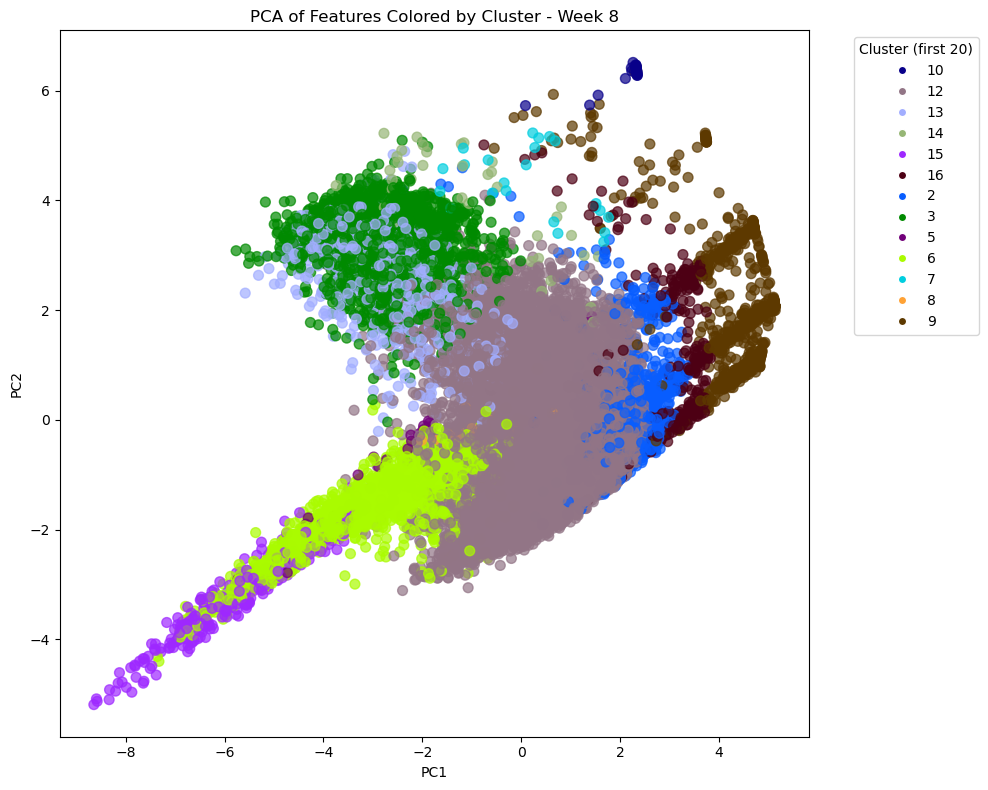

Week 10 - Explained variance ratio for first 2 components: [0.15858119 0.09996607]
Week 10 - Total variance explained by first 2 components: 0.25854726217157487


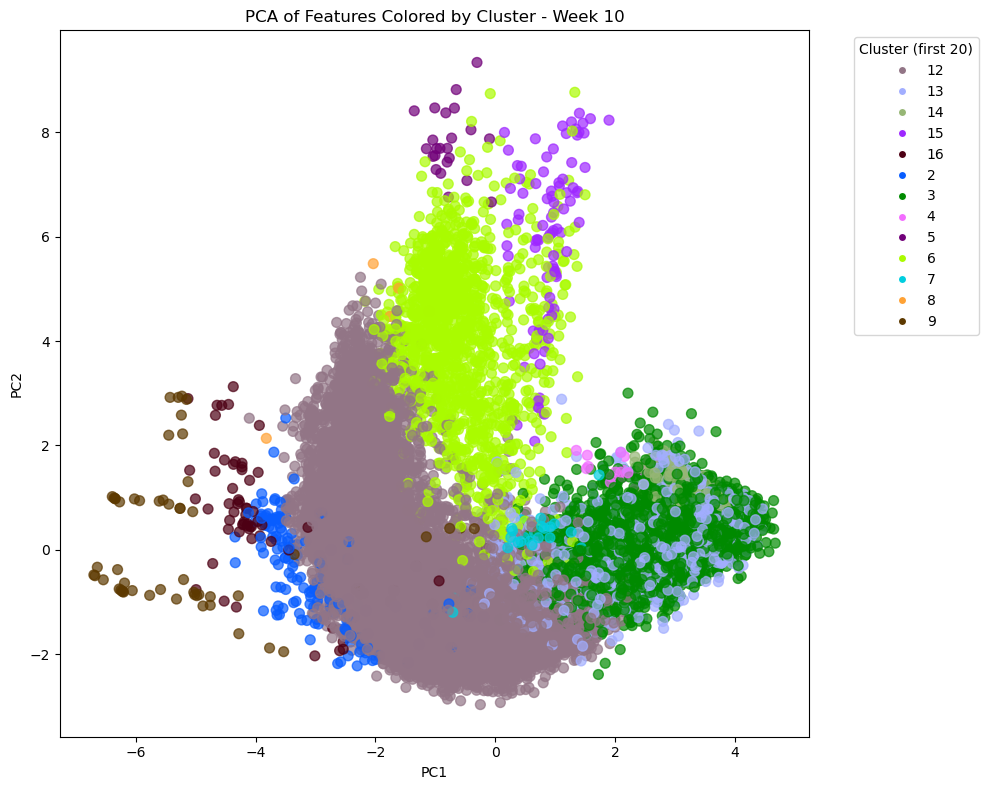

Week 12 - Explained variance ratio for first 2 components: [0.15541691 0.10867072]
Week 12 - Total variance explained by first 2 components: 0.2640876335549794


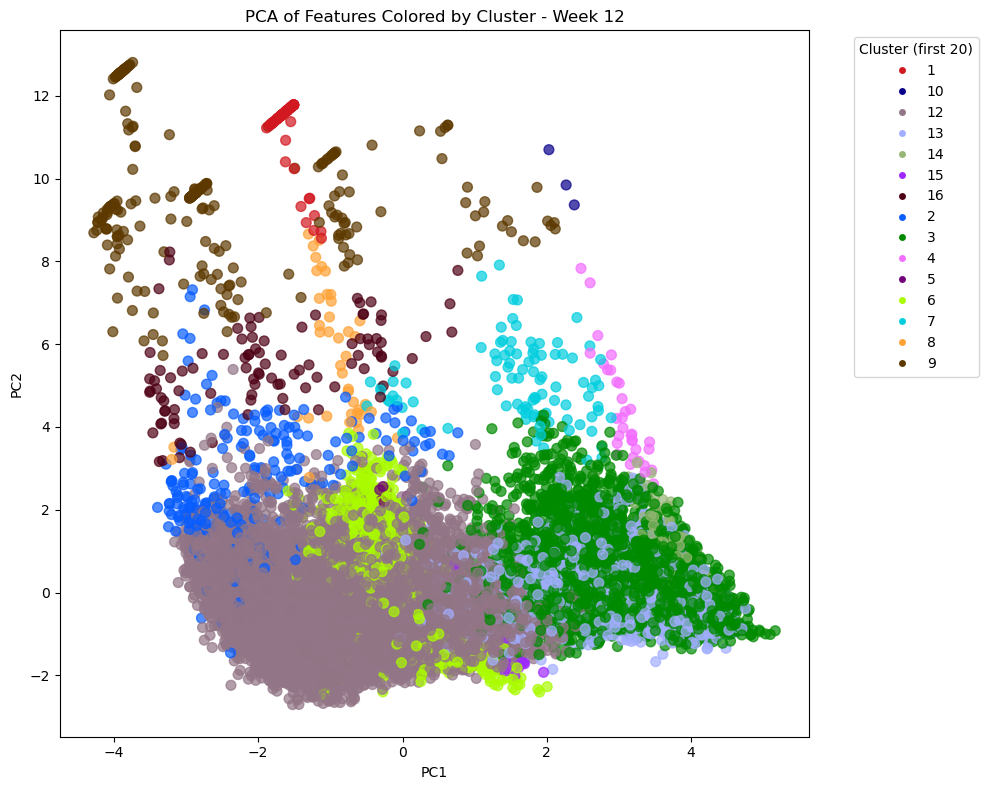

Week 14 - Explained variance ratio for first 2 components: [0.14533576 0.10579513]
Week 14 - Total variance explained by first 2 components: 0.2511308829205599


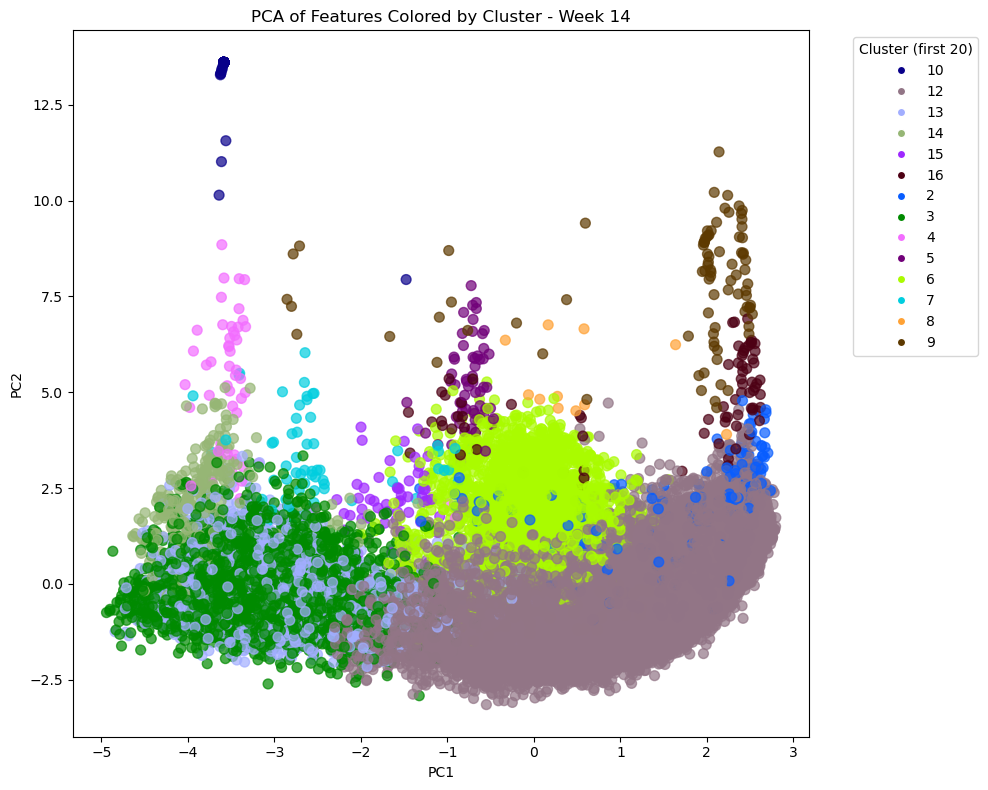

Week 18 - Explained variance ratio for first 2 components: [0.1638972  0.13830563]
Week 18 - Total variance explained by first 2 components: 0.30220282259166775


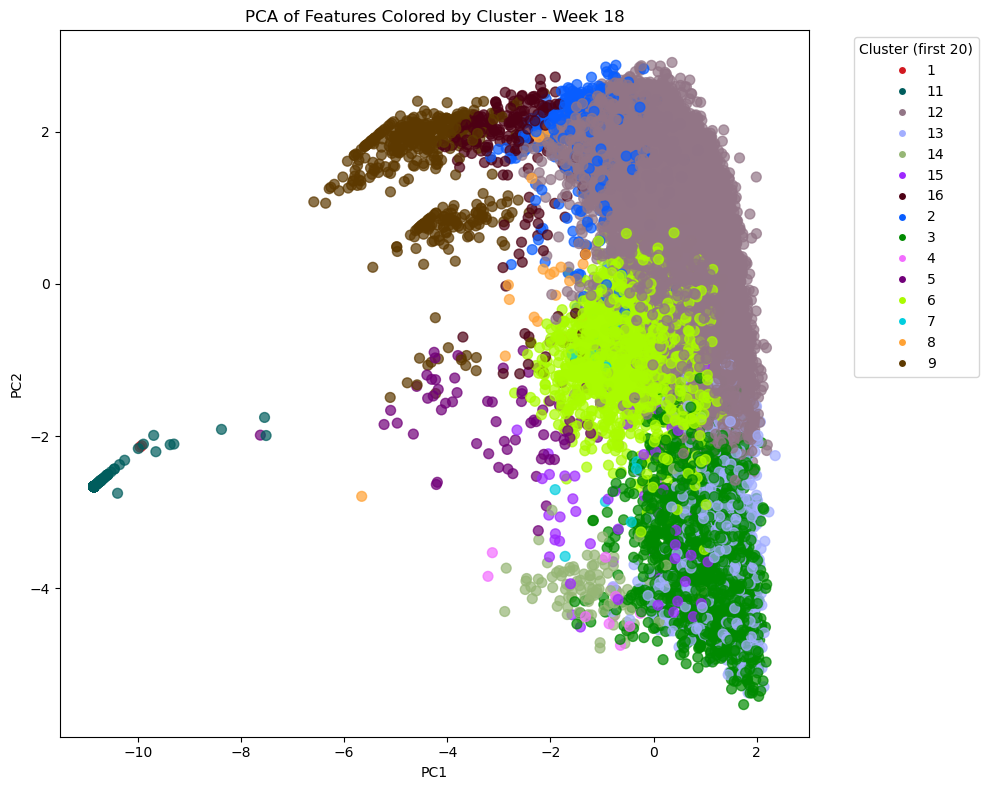

In [10]:
# --- Define features ---
feature_cols = [f"Feature{i}" for i in range(1, 31)]  

# --- Plot PCA for each week separately ---
weeks = sorted(data['Week_Number'].unique())

for week in weeks:
    week_data = data[data['Week_Number'] == week].copy()
    
    # Extract features for this week
    X = week_data[feature_cols].values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Run PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)
    week_data['PCA1'] = pca_result[:, 0]
    week_data['PCA2'] = pca_result[:, 1]
    
    # Print explained variance for this week
    print(f"Week {week} - Explained variance ratio for first 2 components:", pca.explained_variance_ratio_)
    print(f"Week {week} - Total variance explained by first 2 components:", pca.explained_variance_ratio_.sum())
    
    # Map cluster colors (same Glasbey palette)
    # week_data['cluster_str'] = week_data['Cluster'].astype(str)
    # week_data['color'] = week_data['cluster_str'].map(cluster_to_color)
    
    week_data['group_str'] = week_data['Group'].astype(str)
    week_data['color'] = week_data['group_str'].map(cluster_to_color)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(
        week_data['PCA1'],
        week_data['PCA2'],
        c=week_data['color'],
        s=50,
        alpha=0.7
    )
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA of Features Colored by Cluster - Week {week}")
    
    # Optional legend (first 20 clusters for readability)
    # unique_clusters = sorted(week_data['cluster_str'].unique())
    unique_groups = sorted(week_data['group_str'].unique())
    
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_to_color[c], markersize=6)
        for c in unique_groups[:20]
    ]
    labels = unique_groups[:20]
    plt.legend(handles, labels, title="Cluster (first 20)", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


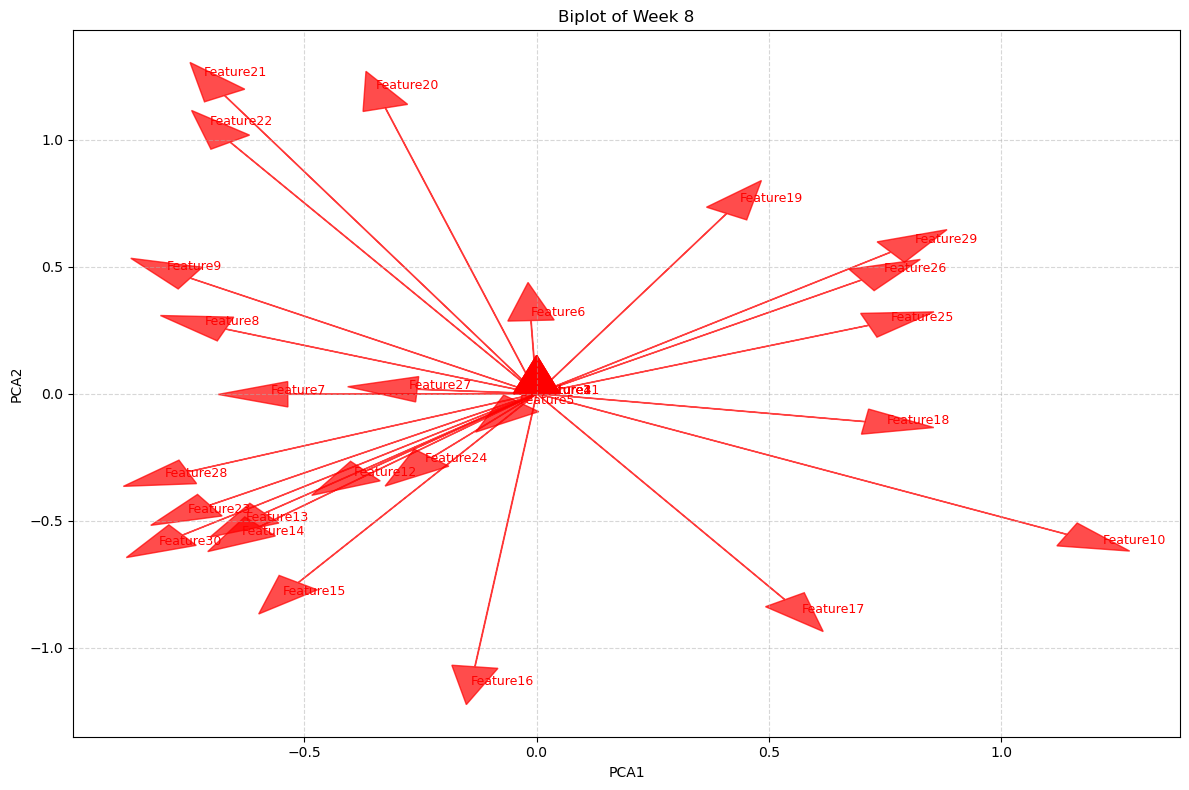

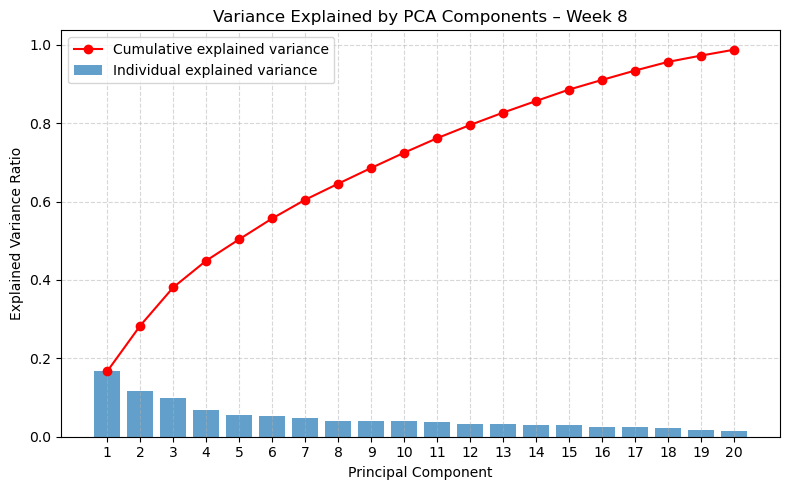

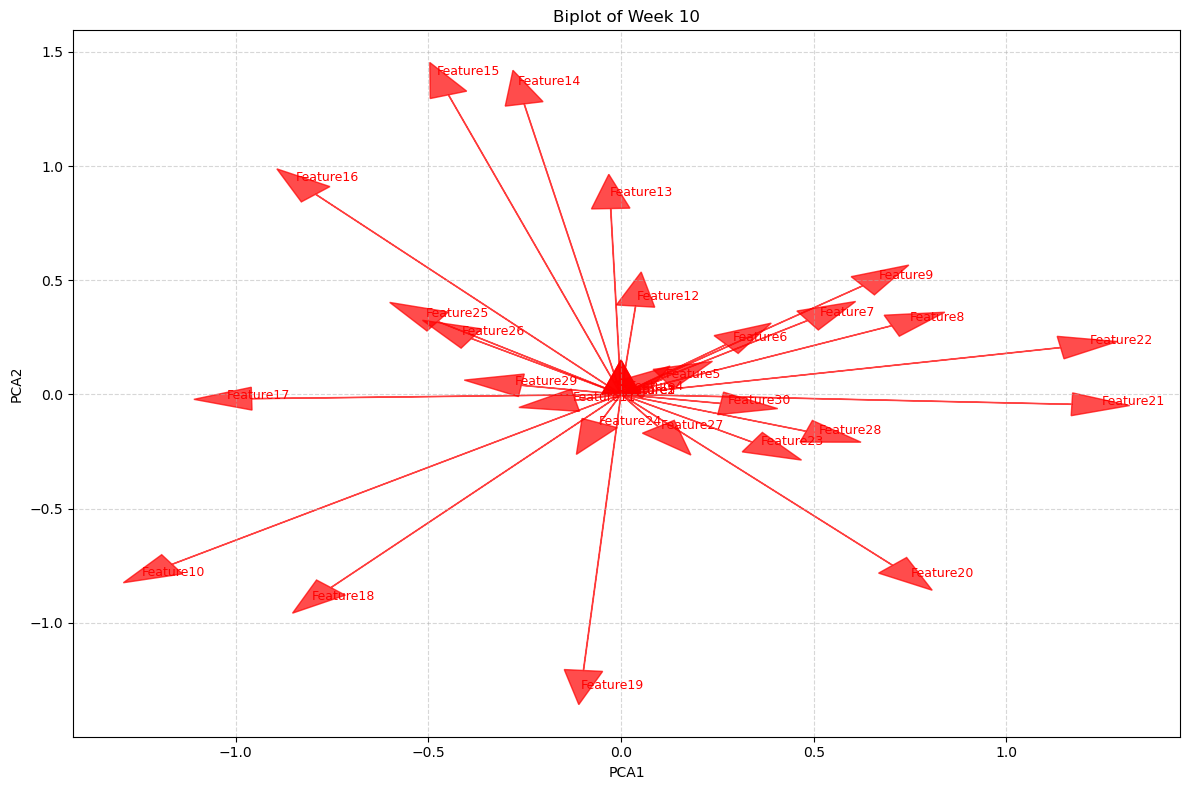

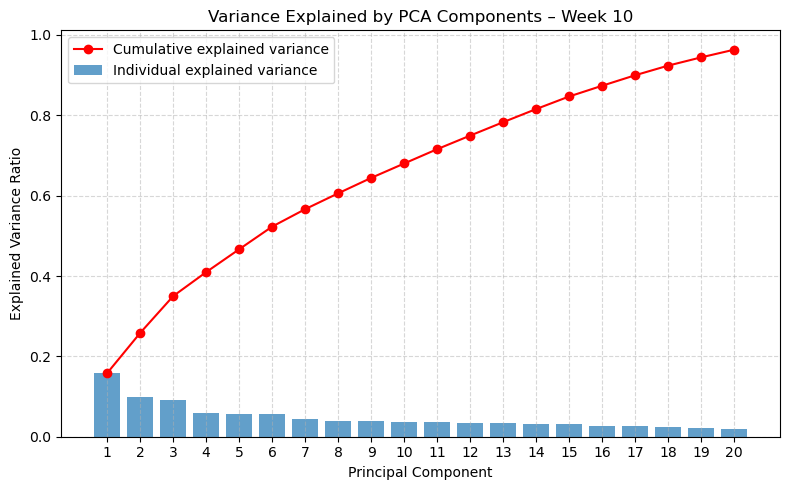

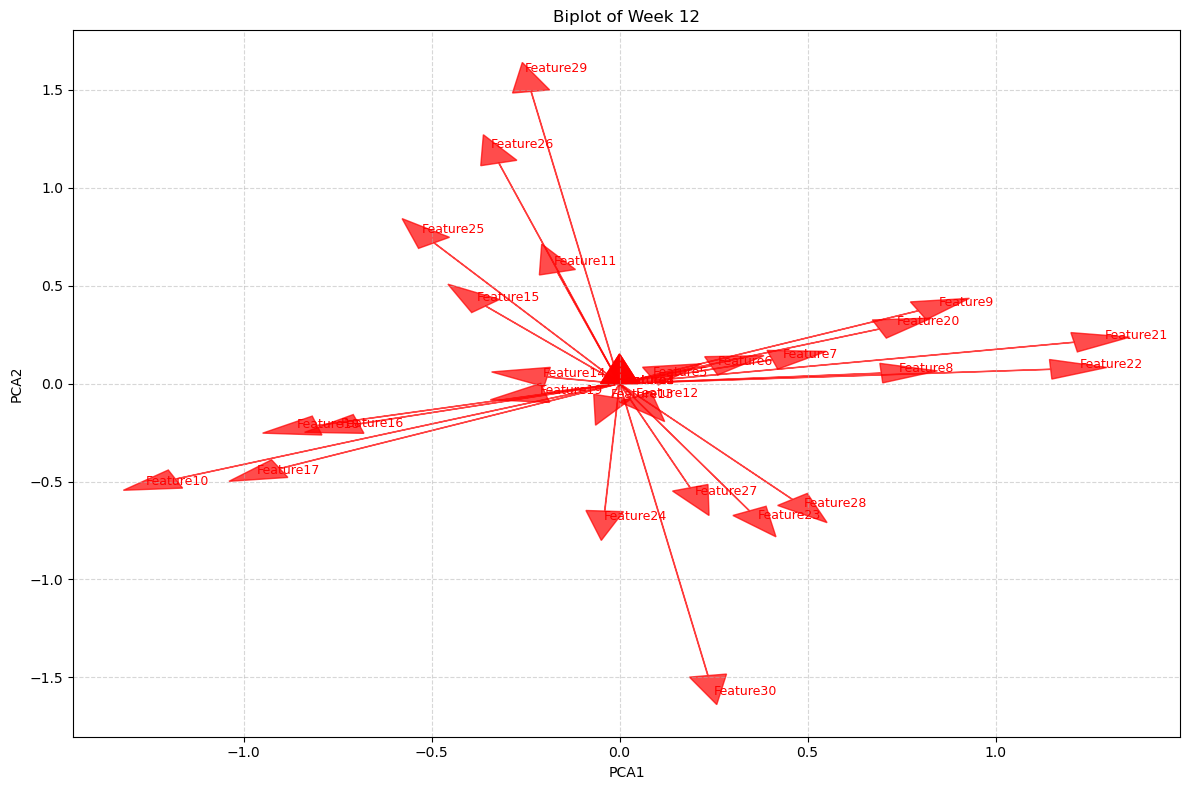

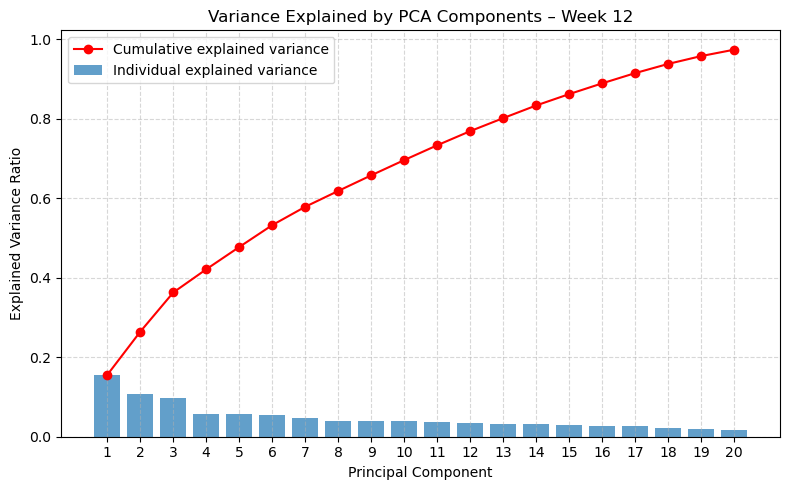

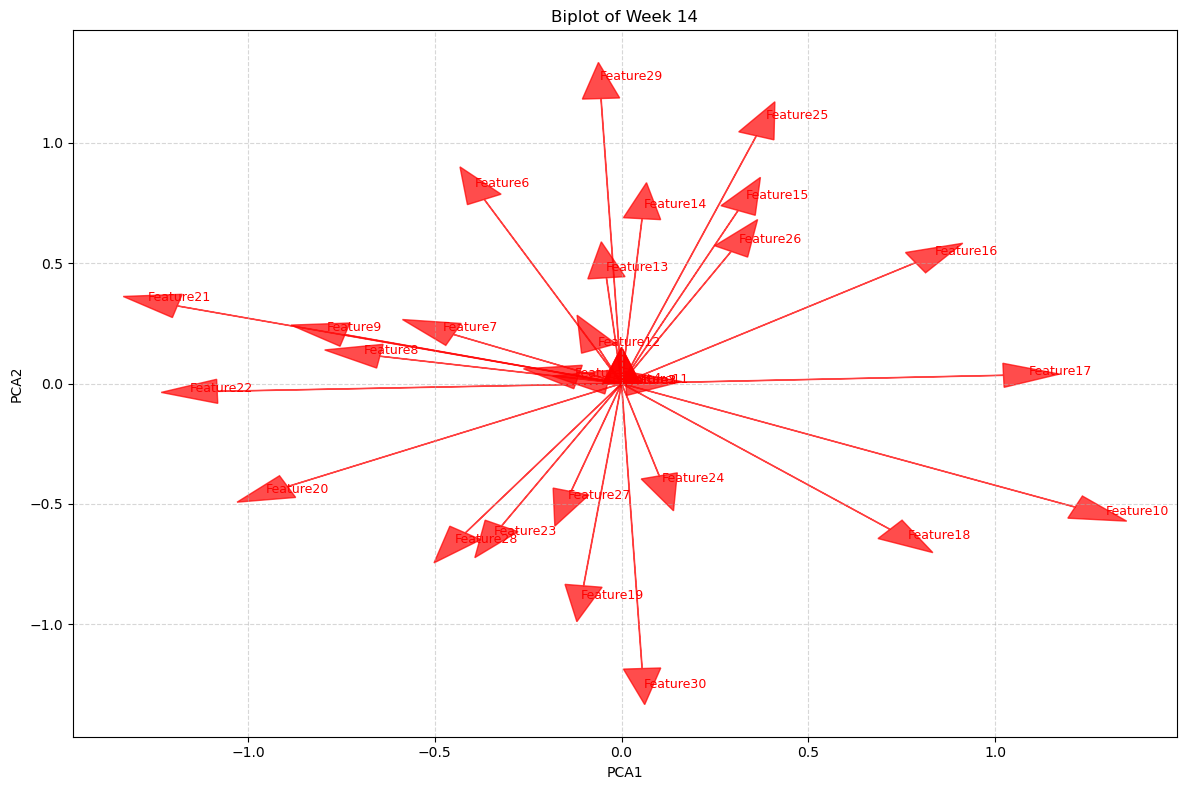

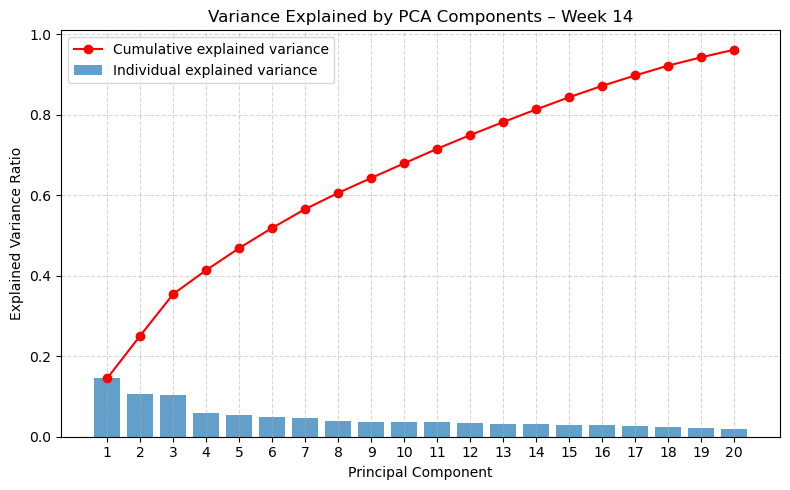

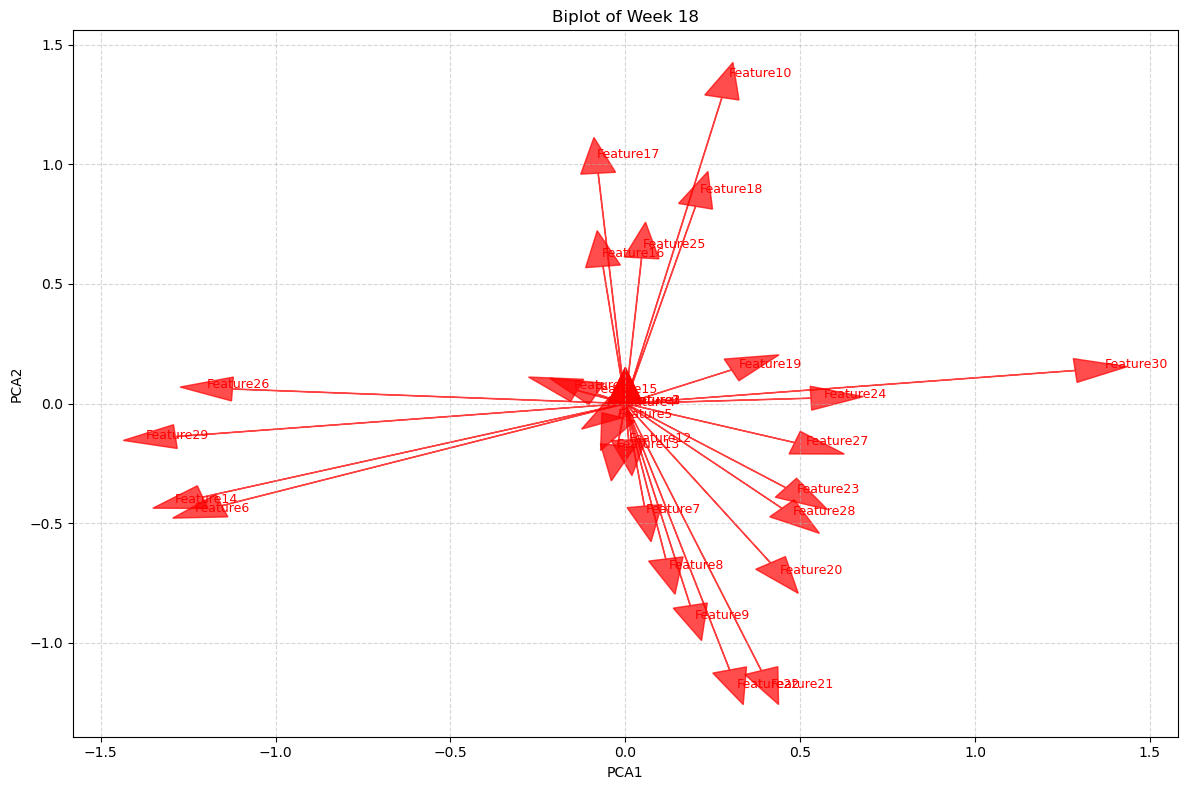

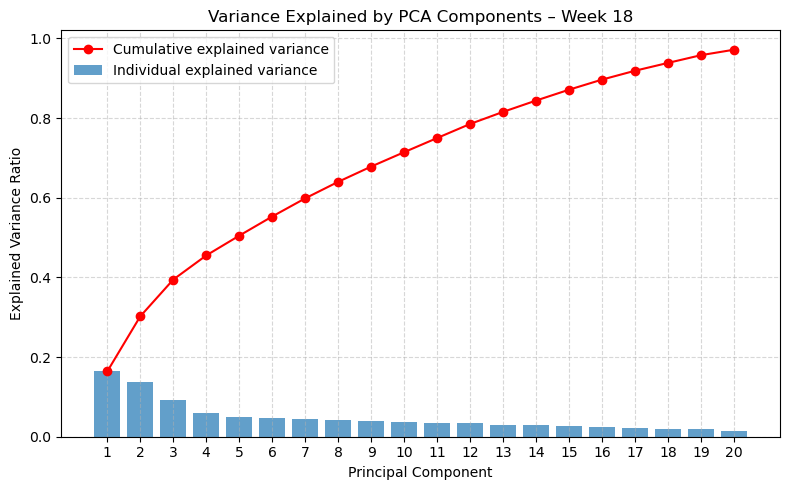

In [ ]:
for week in weeks:
    week_data = data[data['Week_Number'] == week].copy()
    
    # Extract features
    X = week_data[feature_cols].values
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Run PCA
    pca = PCA(n_components=20)
    pca_result = pca.fit_transform(X_scaled)
    week_data['PCA1'] = pca_result[:, 0]
    week_data['PCA2'] = pca_result[:, 1]
    
    # Map cluster colors (using Glasbey)
    week_data['cluster_str'] = week_data['Group'].astype(str)
    week_data['color'] = week_data['cluster_str'].map(cluster_to_color)
    
    # --- Biplot ---
    plt.figure(figsize=(12, 8))
    
    # Plot scores (samples)
    # plt.scatter(
    #     week_data['PCA1'],
    #     week_data['PCA2'],
    #     c=week_data['color'],
    #     s=50,
    #     alpha=0.7
    # )
    
    # Plot feature vectors (loadings)
    loadings = pca.components_.T  # shape: n_features x 2
    for i, feature in enumerate(feature_cols):
        plt.arrow(0, 0, 
                  loadings[i, 0]*3,  # scale factor for visibility
                  loadings[i, 1]*3, 
                  color='red', 
                  alpha=0.7, 
                  head_width=0.1)
        plt.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, feature, color='red', fontsize=9)
    
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.title(f"Biplot of Week {week}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Scree plot
    # plt.figure(figsize=(8, 5))

    # var_exp = pca.explained_variance_ratio_
    # cum_var_exp = var_exp.cumsum()

    # components = range(1, len(var_exp) + 1)

    # # Bars
    # plt.bar(components, var_exp, alpha=0.7, label='Individual explained variance')

    # # Cumulative line
    # plt.plot(components, cum_var_exp, marker='o', color='red', label='Cumulative explained variance')

    # plt.xticks(components)
    # plt.ylabel("Explained Variance Ratio")
    # plt.xlabel("Principal Component")
    # plt.title(f"Variance Explained by PCA Components – Week {week}")
    # plt.grid(True, linestyle='--', alpha=0.5)
    # plt.legend()
    # plt.tight_layout()
    # plt.show()

